# 📊 Cancellation Recovery Analysis

Objective:
Analyze appointment cancellations and patient response behavior to identify key drivers of missed bookings and recommend strategies to improve scheduling efficiency and patient engagement.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving cancellation_recovery_dataset.xlsx to cancellation_recovery_dataset (1).xlsx


In [3]:
import pandas as pd

df = pd.read_excel("cancellation_recovery_dataset.xlsx")
df.head()

,Patient_ID,Therapist,Date,Available_Short_Notice,Outcome,Appointment_Filled,Time_Slot,Contacts_Attempted
0,1,C,2025-03-08,Yes,No Answer,No,Afternoon,4
1,2,K,2025-01-14,No,Declined,No,Morning,4
2,3,R,2025-01-08,Yes,Declined,No,Morning,3
3,4,K,2025-04-20,Yes,Booked,Yes,Morning,2
4,5,K,2025-02-24,Yes,Declined,No,Afternoon,1


In [6]:
df.columns

Index(['Patient_ID', 'Therapist', 'Date', 'Available_Short_Notice', 'Outcome',
       'Appointment_Filled', 'Time_Slot', 'Contacts_Attempted'],
      dtype='object')

In [7]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Clean outcome column
df['outcome'] = df['outcome'].str.strip().str.lower()

df.head()

,patient_id,therapist,date,available_short_notice,outcome,appointment_filled,time_slot,contacts_attempted
0,1,C,2025-03-08,Yes,no answer,No,Afternoon,4
1,2,K,2025-01-14,No,declined,No,Morning,4
2,3,R,2025-01-08,Yes,declined,No,Morning,3
3,4,K,2025-04-20,Yes,booked,Yes,Morning,2
4,5,K,2025-02-24,Yes,declined,No,Afternoon,1


In [8]:
df['outcome'].unique()

array(['no answer', 'declined', 'booked'], dtype=object)

In [9]:
canceled_df = df[df['outcome'] == 'declined']
len(canceled_df)

74

In [10]:
total_appointments = len(df)
total_cancellations = len(canceled_df)

cancellation_rate = (total_cancellations / total_appointments) * 100

print("Total Appointments:", total_appointments)
print("Total Cancellations:", total_cancellations)
print("Cancellation Rate:", round(cancellation_rate, 2), "%")

Total Appointments: 200
Total Cancellations: 74
Cancellation Rate: 37.0 %


In [11]:
df['outcome'].value_counts()

,count
outcome,
no answer,76
declined,74
booked,50


In [12]:
cancel_by_time = canceled_df['time_slot'].value_counts()
print(cancel_by_time)

time_slot
Morning      39
Afternoon    35
Name: count, dtype: int64


In [13]:
cancel_by_therapist = canceled_df['therapist'].value_counts()
print(cancel_by_therapist)

therapist
R    30
K    27
C    17
Name: count, dtype: int64


In [14]:
canceled_df['contacts_attempted'].value_counts()

,count
contacts_attempted,
3,18
1,18
2,16
4,11
5,11


In [15]:
canceled_df['available_short_notice'].value_counts()

,count
available_short_notice,
Yes,41
No,33


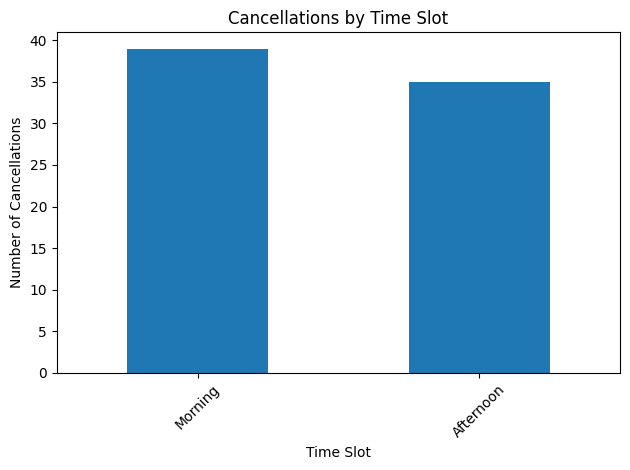

In [16]:
import matplotlib.pyplot as plt

cancel_by_time.plot(kind='bar')
plt.title("Cancellations by Time Slot")
plt.xlabel("Time Slot")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
total_appointments = len(df)
total_cancellations = len(canceled_df)

cancellation_rate = (total_cancellations / total_appointments) * 100

print("Total Appointments:", total_appointments)
print("Total Cancellations:", total_cancellations)
print("Cancellation Rate:", round(cancellation_rate, 2), "%")

Total Appointments: 200
Total Cancellations: 74
Cancellation Rate: 37.0 %


In [18]:
df['outcome'].value_counts()

,count
outcome,
no answer,76
declined,74
booked,50


contacts_attempted
3    18
1    18
2    16
4    11
5    11
Name: count, dtype: int64


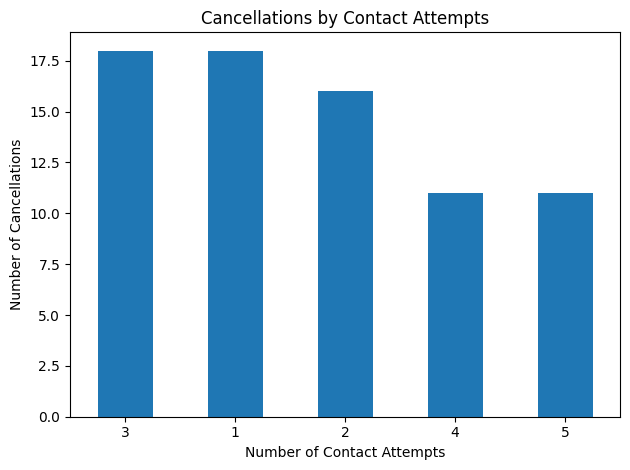

In [19]:
cancel_by_contacts = canceled_df['contacts_attempted'].value_counts()
print(cancel_by_contacts)

cancel_by_contacts.plot(kind='bar')
plt.title("Cancellations by Contact Attempts")
plt.xlabel("Number of Contact Attempts")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

cancel_by_contacts = canceled_df['contacts_attempted'].value_counts()
print(cancel_by_contacts)

cancel_by_contacts.plot(kind='bar')
plt.title("Cancellations by Contact Attempts")
plt.xlabel("Number of Contact Attempts")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()